In [1]:
#My research investigates whether 
#organisational-level NHS stroke service indicators
#can be used to predict high stroke unit performance using machine learning models.

#Imports:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

import matplotlib.pyplot as plt

In [3]:
# Data Loading Function:

def load_clean(file_path, header_row):

    df = pd.read_excel(file_path, header=header_row)
    df.columns = df.columns.str.strip()

    org_col = [col for col in df.columns if "Org" in col or "Organisation" in col][0]

    df = df.dropna(subset=[org_col])
    df = df[df[org_col] != "England"]

    return df

# Function to load and clean NHS stroke datasets:
# I created a reusable function to clean and standardise the NHS datasets.
# I combined multiple quarterly datasets into a single dataframe of 608 observations.

In [5]:
# Load NHS datsets:

df_q1 = load_clean("../../data/raw/Stroke-Web-file-Q1-2012-13-revised-15.05.2013.xls", 13)
df_q2 = load_clean("../../data/raw/Stroke-Web-file-Q2-2012-13-revised-15.05.2013.xls", 13)
df_q3 = load_clean("../../data/raw/Stroke-Web-file-Q3-2012-13-revised-15.05.2013.xls", 13)
df_q4 = load_clean("../../data/raw/Stroke-Web-file-Q4-2012-13.xls", 13)

In [7]:
# Combine datasets:

df = pd.concat([df_q1, df_q2, df_q3, df_q4], ignore_index=True)

df.shape

(604, 9)

In [9]:
# Creating target variable:

df["High_Performance"] = (
    df["Percentage of patients who spend at least 90% of their time on a stroke unit"] > 0.85
).astype(int)

df["High_Performance"].value_counts()

High_Performance
1    333
0    271
Name: count, dtype: int64

In [11]:
# Feature preparation:

df_model = df[[
    "Number of people who were admitted to hospital following a stroke",
    "Quarter",
    "SHA",
    "High_Performance"
]]

df_model = pd.get_dummies(df_model, columns=["Quarter", "SHA"], drop_first=True)

In [13]:
# Train and test split:

X = df_model.drop("High_Performance", axis=1)
y = df_model["High_Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train.shape, X_test.shape

((422, 13), (182, 13))

In [15]:
# Logistic Regression model:

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6483516483516484
              precision    recall  f1-score   support

           0       0.61      0.62      0.61        82
           1       0.68      0.67      0.68       100

    accuracy                           0.65       182
   macro avg       0.65      0.65      0.65       182
weighted avg       0.65      0.65      0.65       182



In [17]:
# Receiver Operation Characteristic & Area Under the Curve:

y_prob = log_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

AUC: 0.7242682926829269


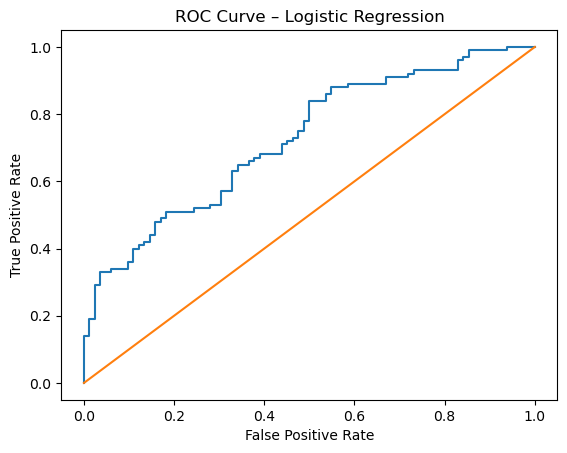

In [19]:
# ROC Curve:

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.show()

In [21]:
# Cross validation:

cv_scores = cross_val_score(log_model, X, y, cv=5)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

CV Scores: [0.69421488 0.62809917 0.45454545 0.56198347 0.61666667]
Mean CV Accuracy: 0.5911019283746557
Std Dev: 0.08018751407768719
